In [21]:
import os, random, sys, warnings, copy
import numpy as np
from scipy.spatial import distance
import pandas as pd
import bct
from tqdm import tqdm

import neurogym as ngym
import torch
import torch.nn as nn

sys.path.extend(['/Users/ahmad/software/snaplab_github/neuro_rnn', '/Users/ahmad/software/snaplab_github/neuro_rnn/packages/neurogym'])

from src.neural_network import RNN, run_training, run_testing
from src.utils import normalize_x, fix_labels, get_weight_masks_schaefer, get_file_str

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 12})
plt.rcParams["svg.fonttype"] = "none"
import seaborn as sns
from src.plotting import plot_activity, plot_iodata

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

### Device configuration

First, let's set the torch device! We need to tell pytorch whether we are going to train our model using the cpu, CUDA (nvidia gpu only) or Metal Performance Shaders (MPS; for mac). Note, I tried using MPS on my M2 Pro Macbook Pro but it was wayyy slower than just using the CPU.

In [22]:
if sys.platform == 'linux':  # if your system is running Linux
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # check if cuda is available, if not, use the cpu
elif sys.platform == 'darwin':  # if your system is running Mac OS
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')  # MPS seems to be slow for RNNs here
    device = torch.device('cpu')  # use the cpu
print(device)

cpu


### Set params

In [23]:
# directories (ahmad, you will need to edit these!)
if sys.platform == 'linux':
    datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
    outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'
elif sys.platform == 'darwin':
    datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
    outdir = '/Users/ahmad/software/snaplab_github/neuro_rnn/results/figs'

# data parameters
task = 'PerceptualDecisionMaking-v0'  # options: ['PerceptualDecisionMaking-v0', 'MultiSensoryIntegration-v0', 'ContextDecisionMaking-v0']
dt = 100  # don't change
batch_size = 16  # tweak as much as you like!
decision = 300  # options: [100, 200, 300, 400]
if task == 'PerceptualDecisionMaking-v0':
    seq_len = 22
elif task == 'MultiSensoryIntegration-v0':
    seq_len = 11
elif task == 'ContextDecisionMaking-v0':
    seq_len = 13
seq_len = seq_len + int((decision - 100) / dt)
seq_len_multi = 5  # feel free to modify the integer multiplier here. it controls how many task trials are represented in a single stimulus train
seq_len = seq_len * seq_len_multi

# RNN model and training parameters
rnn_model = 'rnn-tanh'  # options: ['rnn-tanh', 'rnn-relu', 'lstm', 'gru']
hidden_size = 100  # options: [50, 100, 200]
n_epochs = 5000  # options: any integer value
lr = 0.001  # can change, but wouldn't bother right noe

# regularization parameters
kernel_type = 'sa_axis'  # options: ['sa_axis', 'euclidean', None]
reg_type = 'l2'  # options: ['l1', 'l2']
reg_weight = 0.001  # options: [0.0001, 0.001, 0.002]
mask_weights = True  # options: [True, False]

In [24]:
# leave all this stuff alone. This code just compiles all the above settings into config.
if task == 'ContextDecisionMaking-v0':
    timing = {'fixation': 200, 'stimulus': 1000, 'delay': 0, 'decision': decision}
else:
    timing = {'decision': decision}
env_kwargs = {'dt': dt, 'timing': timing}

config = {
    'datadir': datadir, 'outdir': outdir,
    'task': task, 'dt': dt, 'seq_len': seq_len, 'batch_size': batch_size,  # data parameters
    'rnn_model': rnn_model, 'hidden_size': hidden_size, 'n_runs': 1, 'n_epochs': n_epochs, 'lr': lr, 'mask_weights': mask_weights,  # RNN model and training parameters
    'kernel_type': kernel_type, 'reg_type': reg_type, 'reg_weight': reg_weight,  # regularization parameters
    'env_kwargs': env_kwargs
}

### Environment: make dataset

3 3
(120, 16, 3) (120, 16)


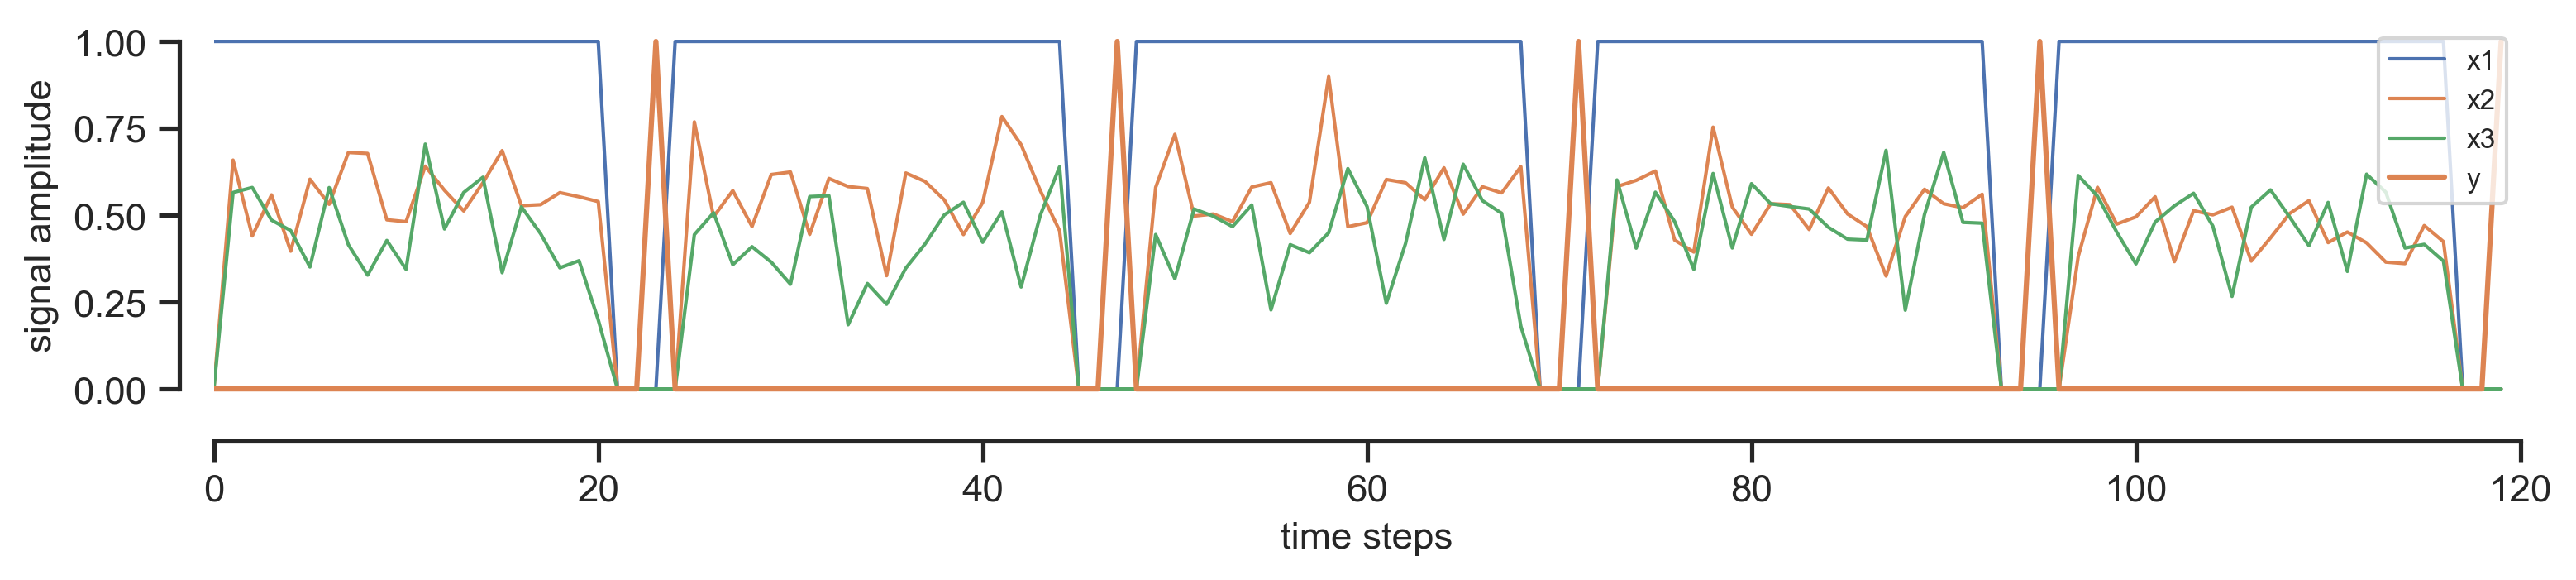

In [25]:
dataset = ngym.Dataset(config['task'], env_kwargs=env_kwargs, batch_size=config['batch_size'], seq_len=config['seq_len'])
input_size = dataset.env.observation_space.shape[0]
num_classes = dataset.env.action_space.n
print(input_size, num_classes)

# plot
inputs, labels = dataset()
trim = int((decision - 100) / dt)
labels = fix_labels(labels, decision=int(decision / dt), trim=trim)
print(inputs.shape, labels.shape)

# plot input/output (x/y) data
plot_iodata(
    inputs[:, 0, :], labels[:, 0],
    rc_params={'figure.dpi': 300, 'savefig.dpi': 300},
    show=True, ax_params={'xlim': [0, seq_len]}
)

For the perceptual decision making task, the above plots shows 3 inputs (x1, x2, x3) and a single output (y). Separate trials are simply stiched end-to-end. The number of trials you see will depend upon seq_len_multi.

### Setup weight masks

Here, we read in the node info from the Schaefer parcellation to build masks for our RNN. We use these masks to restrict which RNN neurons receive task inputs (x1, x2, x3) and which RNN neurons we read outputs from. Here, we designate visual nodes to receive task inputs and default mode nodes to read outputs from.

In [26]:
# weight masks
centroids = pd.read_csv(os.path.join(datadir, 'schaefer{0}_centroids.csv'.format(hidden_size * 2)))
centroids = centroids[:hidden_size]
roi_names = list(centroids['ROI Name'])
input_system = 'Vis'
output_system = 'Default'
masks = get_weight_masks_schaefer(roi_names=roi_names, input_system=input_system, output_system=output_system)

if mask_weights:
    n_io = '{0}-{1}'.format(np.sum(masks['input_weight_mask']), np.sum(masks['output_weight_mask']))
else:
    n_io = 'na'
config['n_io'] = n_io
print(n_io)

14-27


### Plot weight masks

And here are those masks plotted as simple heatmaps. These are binary masks. The input mask comrpises the visual nodes. The output mask comprises the default mode nodes. The bystander masks is just everything else; we don't use this mask for training.

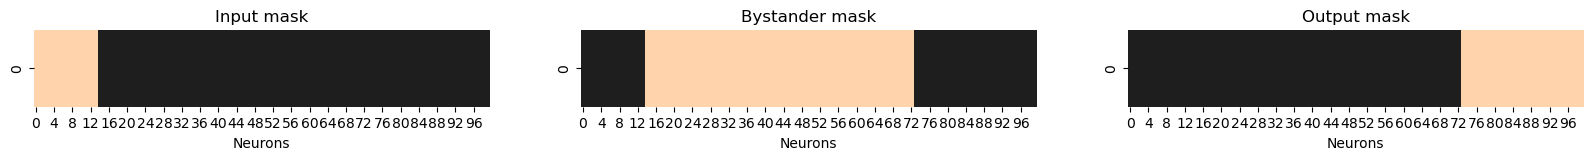

In [27]:
f, ax = plt.subplots(1, 3, figsize=(20, 1))
sns.heatmap(masks['input_weight_mask'][np.newaxis], ax=ax[0], square=False, center=0, cbar=False)
ax[0].set_title('Input mask')
ax[0].set_xlabel('Neurons')
sns.heatmap(masks['bystanders'][np.newaxis], ax=ax[1], square=False, center=0, cbar=False)
ax[1].set_title('Bystander mask')
ax[1].set_xlabel('Neurons')
sns.heatmap(masks['output_weight_mask'][np.newaxis], ax=ax[2], square=False, center=0, cbar=False)
ax[2].set_title('Output mask')
ax[2].set_xlabel('Neurons')
plt.show()

The below plots simply show all the possible combinations of the above 3 masks. For example, the first mask matrix (input_output) masks all the edges connecting input nodes to output nodes. These masks aren't used at all in this notebook, but they are useful if we want to do lesion analysis! For example, we could examine how performance of a trained RNN is impacted when we lesion all the weights connecting the input nodes directly to the output nodes (we'd use input_output...).

In [28]:
mask_labels = ['input_input', 'bystanders_bystanders', 'output_output',
               'input_output', 'output_input',
               'input_bystanders', 'bystanders_input',
               'output_bystanders', 'bystanders_output']
n_masks = len(mask_labels)

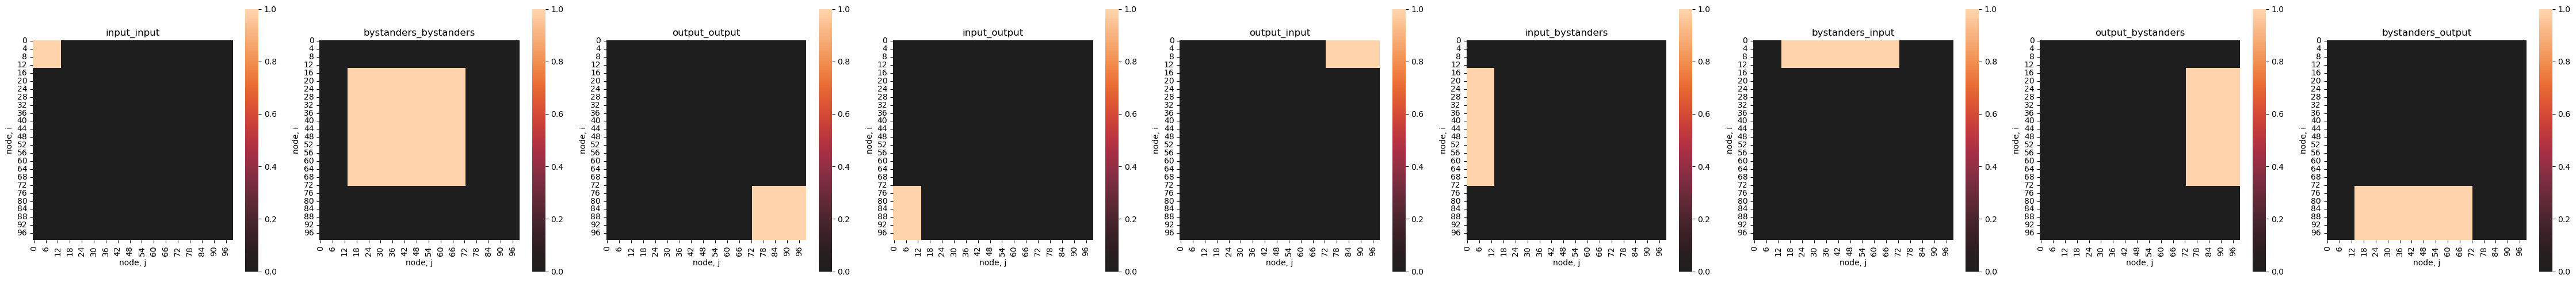

In [29]:
f, ax = plt.subplots(1, n_masks, figsize=(n_masks*5, 5))
for i, mask in enumerate(mask_labels):
    sns.heatmap(masks[mask], ax=ax[i], square=True, center=0)
    ax[i].set_title(mask)
    ax[i].set_xlabel('node, j')
    ax[i].set_ylabel('node, i')
f.tight_layout()
plt.show()

### Setup regularization kernel (for spatial embedding)

The below code sets up the kernel (matrix) we use for spatially embedding RNN nodes. We will use this kernel to pernalize weight formation throughout training.

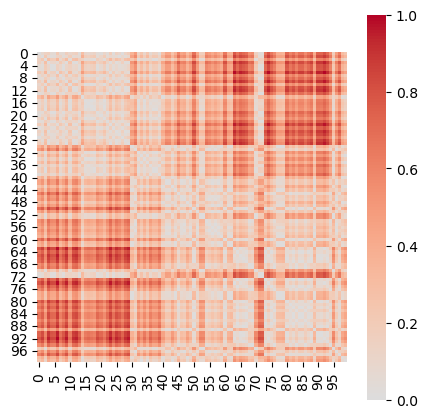

In [30]:
if kernel_type is None:
    # no distance penalty
    regularization_kernel = None
elif kernel_type == 'euclidean':
    # static distance matrix for regularization
    centroids = pd.read_csv(os.path.join(datadir, 'schaefer{0}_centroids.csv'.format(hidden_size * 2)))
    if sys.platform == 'darwin':
        centroids.drop(columns='ROI Label', inplace=True)
    centroids = centroids[:hidden_size]
    centroids.set_index("ROI Name", inplace=True)
    distance_matrix = distance.pdist(centroids, "euclidean")  # get euclidean distances between nodes
    distance_matrix = distance.squareform(distance_matrix)  # reshape to square matrix
    regularization_kernel = normalize_x(distance_matrix)
elif kernel_type == 'sa_axis':
    sa_axis = np.load(os.path.join(datadir, 'schaefer{0}_sa-axis.npy'.format(hidden_size * 2)))
    sa_axis = sa_axis[:hidden_size]
    n = len(sa_axis)
    distance_matrix = np.zeros((n, n))
    for i in np.arange(n):
        for j in np.arange(n):
            distance_matrix[i, j] = sa_axis[i] - sa_axis[j]
    distance_matrix = np.abs(distance_matrix)
    regularization_kernel = normalize_x(distance_matrix)

# plot
if regularization_kernel is None:
    pass
elif regularization_kernel.ndim == 2:
    f, ax = plt.subplots(1, 1, figsize=(5, 5))
    sns.heatmap(regularization_kernel, ax=ax, square=True, cmap='coolwarm', center=0)
    plt.show()
elif regularization_kernel.ndim == 3:
    f, ax = plt.subplots(1, 4, figsize=(20, 5))
    sns.heatmap(regularization_kernel[:, :, 0], ax=ax[0], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[0].set_title('Epoch 0')
    sns.heatmap(regularization_kernel[:, :, int(n_epochs*.33)], ax=ax[1], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[1].set_title('Epoch {0}'.format(int(n_epochs*.33)))
    sns.heatmap(regularization_kernel[:, :, int(n_epochs*.66)], ax=ax[2], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[2].set_title('Epoch {0}'.format(int(n_epochs*.66)))
    sns.heatmap(regularization_kernel[:, :, -1], ax=ax[3], square=True, cmap='coolwarm', center=0, vmax=1)
    ax[3].set_title('Epoch {0}'.format(int(n_epochs)))
plt.show()

### Train model

Train the model! We first define our RNN and then us run_training to train it. Check out src.neural_network

In [31]:
run = 0
random.seed(run)
np.random.seed(run)
torch.manual_seed(run)
torch.cuda.manual_seed(run)
torch.cuda.manual_seed_all(run)

In [32]:
# setup weight masks
if mask_weights:
    input_weight_mask = masks['input_weight_mask']
    output_weight_mask = masks['output_weight_mask']
else:
    input_weight_mask = None
    output_weight_mask = None
    print(input_weight_mask, output_weight_mask)

In [33]:
# initialize the model
model = RNN(input_size=input_size, hidden_size=hidden_size, num_classes=num_classes, type=rnn_model,
            regularization_kernel=regularization_kernel,
            input_weight_mask=input_weight_mask, output_weight_mask=output_weight_mask).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
scheduler = None
tra_loss, val_loss, tes_acc = run_training(dataset=dataset, model=model, optimizer=optimizer, criterion=criterion, config=config, scheduler=scheduler, return_models=False)

epoch 100 | running training loss: 0.36733 | running validation loss: 0.34528 | test accuracy: 0.00%
epoch 200 | running training loss: 0.22579 | running validation loss: 0.21495 | test accuracy: 0.00%
epoch 300 | running training loss: 0.22224 | running validation loss: 0.21318 | test accuracy: 0.00%
epoch 400 | running training loss: 0.21945 | running validation loss: 0.21190 | test accuracy: 0.00%
epoch 500 | running training loss: 0.21723 | running validation loss: 0.21093 | test accuracy: 0.00%
epoch 600 | running training loss: 0.21543 | running validation loss: 0.21013 | test accuracy: 0.00%
epoch 700 | running training loss: 0.21388 | running validation loss: 0.20942 | test accuracy: 0.00%
epoch 800 | running training loss: 0.20618 | running validation loss: 0.20159 | test accuracy: 0.00%
epoch 900 | running training loss: 0.06533 | running validation loss: 0.05647 | test accuracy: 53.00%
epoch 1000 | running training loss: 0.04222 | running validation loss: 0.03452 | test accu

### Test model

now we use run_testing to assess performance of the fully trained model as well as pull out some other stuff like activity of the hidden neurons over time (hidden_activity), the activity of the output nodes (output_activity), and trial info. See src.neural_network

In [34]:
n_trials = 100
model.eval()
accuracy, inputs, labels, hidden_activity, output_activity, info = run_testing(dataset=dataset, model=model, n_trials=n_trials)

Average accuracy across 100 trials: 86.00%


In [35]:
print(inputs.shape)  # (n_trials, n_timepoints, input_size)
print(labels.shape)  # (n_trials, n_timepoints) --> n_timepoints = 24
print(hidden_activity.shape)  # (n_trials, n_timepoints, hidden_size)
print(output_activity.shape)  # (n_trials, n_timepoints, input_size)

(100, 24, 3)
(100, 24)
(100, 24, 100)
(100, 24, 3)


# Plot

### Plot activity

Here we plot the activity of the hidden neurons (averaged over nodes) as a function of the choice the RNN made for a bunch of trials (which are also averaged over). If run_pca=True, then activity is shown projected to the top 2 PCs.

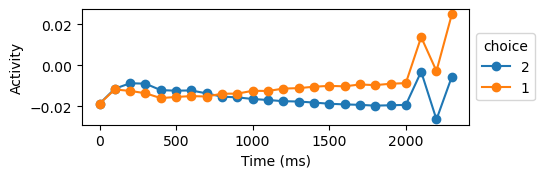

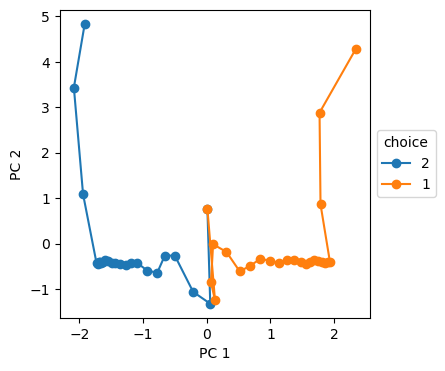

In [37]:
run_pca=False
plot_activity(hidden_activity, info, config, run_pca=run_pca)

run_pca=True
plot_activity(hidden_activity, info, config, run_pca=run_pca)

### Plot training curves and weights

Finally, we'll plot the training curve alongside all the RNN weights.

The first plot shows the training curves. Training (and validation) loss is shown on the left y-axis, and out-of-sample test accuracy (%) is shown on the right y-axis. Note, we store loss for every epoch, but only calculate accuracy for every 100th epoch.

The second plot shows the weights mapping the task's inputs (columns) to the RNN neurons (rows).

The third plot shows the weights mapping the RNN neurons (rows) to the output channels of the task (columns). Note, there is a unique output channel for every possible output value of the task's y variable. For the perceptual decision making task, y can take on 3 values (0, 1, 2), so we see 3 output channels.

The fourth plot shows the weight connecting the RNN neurons.

In [38]:
file_str = get_file_str(config)
print(file_str)

task-PerceptualDecisionMaking-v0-120-300_model-rnn-tanh-100-16-0.001-1-5000_wmask-True-14-27_reg-l2-0.001-sa_axis


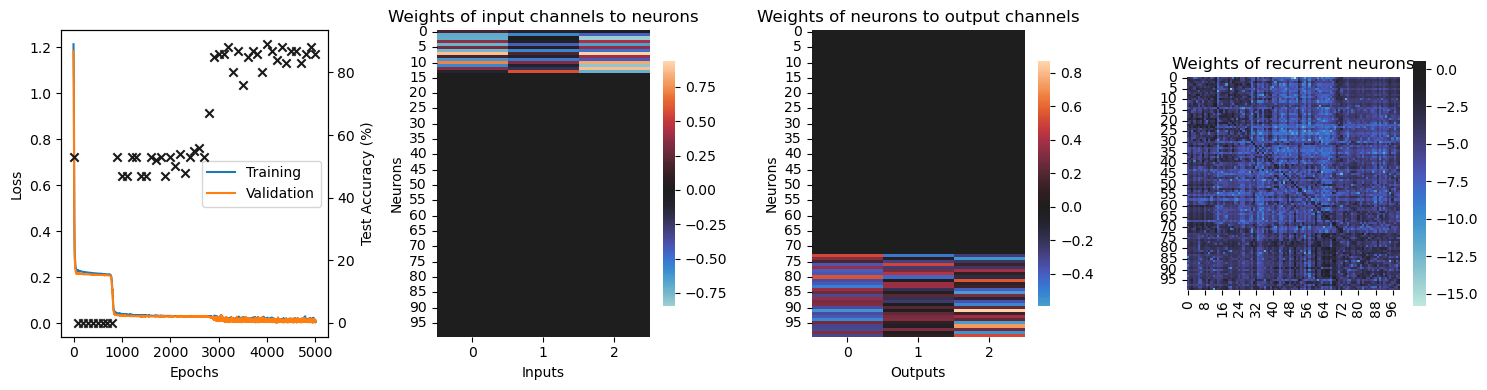

In [39]:
f, ax = plt.subplots(1, 4, figsize=(15, 4))

# performance
sns.lineplot(tra_loss, ax=ax[0], label='Training')
sns.lineplot(val_loss, ax=ax[0], label='Validation')
ax[0].set_ylabel('Loss')
ax0_twin = ax[0].twinx()
ax0_twin.scatter(np.arange(0, n_epochs+100, 100), tes_acc*100, marker='x', c='k')
ax0_twin.set_ylabel('Test Accuracy (%)')
ax[0].set_xlabel('Epochs')
ax[0].legend(loc='center right')

# input weights
sns.heatmap(model.rnn.weight_ih_l0.detach().cpu().numpy(), ax=ax[1], square=False, center=0, cbar_kws={"shrink": 0.80})  # , vmin=-0.5, vmax=0.5
ax[1].set_title('Weights of input channels to neurons')
ax[1].set_xlabel('Inputs')
ax[1].set_ylabel('Neurons')

# output weights
sns.heatmap(model.fc.weight.detach().cpu().numpy().T, ax=ax[2], square=False, center=0, cbar_kws={"shrink": 0.80})
ax[2].set_title('Weights of neurons to output channels')
ax[2].set_xlabel('Outputs')
ax[2].set_ylabel('Neurons')

# hidden weights
h_weights = model.rnn.weight_hh_l0.detach().cpu().numpy()
sns.heatmap(np.log(np.abs(h_weights)), ax=ax[3], square=True, center=0, cbar_kws={"shrink": 0.80})  # , vmin=-0.5, vmax=0.5
ax[3].set_title('Weights of recurrent neurons')

f.tight_layout()
plt.show()
f.savefig(os.path.join(outdir, '{0}_single-run.png'.format(file_str)), dpi=300, bbox_inches='tight', pad_inches=0.01)